<h2>Лабораторна робота №3</h2>
<h3>Дослідження алгоритму нечіткої кластеризації</h3>

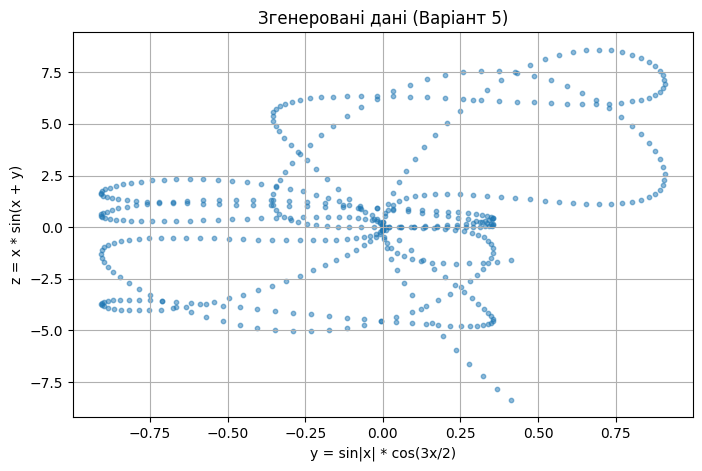

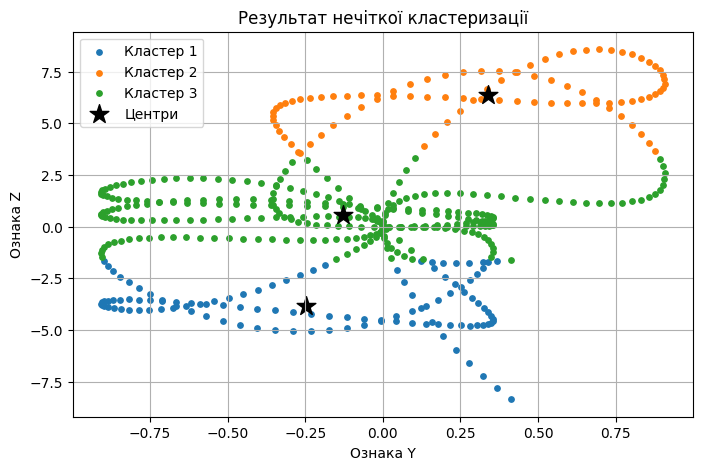

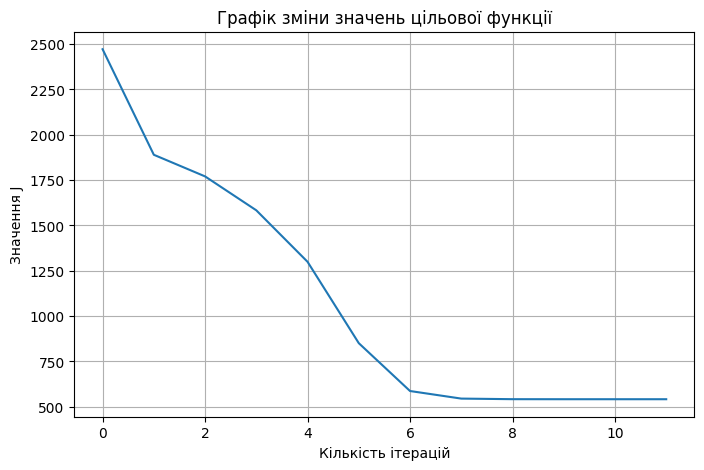

Центри кластерів:
 [[-0.2461118  -3.8406865 ]
 [ 0.33748591  6.3497921 ]
 [-0.12948723  0.57701763]]


In [3]:
# Підключається бібліотека NumPy для роботи з масивами, векторами та математичними операціями
import numpy as np 
# Підключається бібліотека scikit-fuzzy, яка містить алгоритми нечіткої логіки, зокрема Fuzzy C-Means
import skfuzzy as fuzz 
# Підключається бібліотеку Matplotlib для побудови графіків та візуалізації даних
import matplotlib.pyplot as plt 

# 1. Формулювання завдання 
# Завдання: 
# Кластеризація точок складного сигналу/поверхні для стиснення даних або розпізнавання режимів роботи системи.
# Об'єкти задаються векторами [y, z], де y та z обчислені на основі нелінійних залежностей від параметра x.

# 2. Синтез даних згідно з Варіантом 5
# Створюємо діапазон значень x
x_values = np.linspace(-10, 10, 500) # Створюється 500 рівновіддалених значень x у діапазоні від −10 до 10

# Обчислюємо y та z за формулами варіанту
# Обчислюється значення y за формулою варіанту: Варіант 5: y = sin|x| * cos(3x/2)
y_values = np.sin(np.abs(x_values)) * np.cos(3 * x_values / 2) 
# Обчислюєтся значення z за формулою варіанту: Варіант 5: z = x * sin(x + y)
z_values = x_values * np.sin(x_values + y_values)

# Формуємо набір даних (Data matrix: кожна колонка - це спостереження)
# Об’єднується масиви y та z у матрицю даних: кожна колонка — одне спостереження, кожен рядок — окрема ознака
data = np.vstack((y_values, z_values))

# Візуалізація вхідних даних
plt.figure(figsize=(8, 5)) # Створюється нове вікно для графіка з розміром 8×5 дюймів
# Будується точковий графік (scatter plot): alpha=0.5 — напівпрозорість, s=10 — розмір точок
plt.scatter(y_values, z_values, alpha=0.5, s=10) 
plt.title('Згенеровані дані (Варіант 5)') # Надається назву графіку
plt.xlabel('y = sin|x| * cos(3x/2)') # Підпис осі X
plt.ylabel('z = x * sin(x + y)') # Підпис осі Y
plt.grid(True) # Вмикається координатна сітка для зручності аналізу
plt.show() # Зображується графік

# 3. Застосування алгоритму Fuzzy C-Means (FCM)
# Запускається алгоритм нечіткої кластеризації Fuzzy C-Means (FCM) 
# Параметри алгоритму: data — вхідні дані, c=3 — кількість кластерів, m=2 — коефіцієнт розмиття,
#                      error=0.005 — критерій зупинки, maxiter=1000 — максимум ітерацій.
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data, c=3, m=2, error=0.005, maxiter=1000, init=None
)

# Визначення міток (точок) кластерів за максимальним ступенем приналежності
cluster_membership = np.argmax(u, axis=0)

# Візуалізація результатів кластеризації
plt.figure(figsize=(8, 5)) # Створюється нове вікно для результатів кластеризації
for j in range(3): # Обходимо циклом по всіх кластерах
    plt.scatter(data[0, cluster_membership == j], # Відображається точки кожного кластера окремим кольором
                data[1, cluster_membership == j],
                label=f'Кластер {j+1}', s=15)

# Відображаються центри кластерів у вигляді чорних зірок
plt.scatter(cntr[:, 0], cntr[:, 1], marker='*', color='black', s=200, label='Центри')
plt.title('Результат нечіткої кластеризації') # Надається назва графіку
plt.xlabel('Ознака Y') # Підпис осі X
plt.ylabel('Ознака Z') # Підпис осі Y
plt.legend() # Відображається маленьке віконце на графіку, де написано, що означають лінії на графіку
plt.grid(True) # Вмикається координатна сітка для зручності аналізу
plt.show() # Зображується графік

# 4. Графік зміни значень цільової функції
plt.figure(figsize=(8, 5)) # Створюється нове вікно для графіка
plt.plot(jm) # Будується графік зміни значення цільової функції J по ітераціях
plt.title('Графік зміни значень цільової функції') # Надається назва графіку
plt.xlabel('Кількість ітерацій') # Підпис осі X
plt.ylabel('Значення J') # Підпис осі Y
plt.grid(True) # Вмикається координатна сітка для зручності аналізу
plt.show() # Зображується графік

# Виводяться у консоль координати центрів кластерів у просторі ознак Y–Z
print("Центри кластерів:\n", cntr) 

# ==============================================================================
# КОНТРОЛЬНІ ЗАПИТАННЯ:
# ==============================================================================
# 1. Кластеризація — це процес об'єднання об'єктів у групи (кластери) на основі їхньої подібності.
# 2. Класифікація — це навчання з учителем (є мітки класів), кластеризація — навчання без учителя.
# 3. Підходи: ієрархічні, розділяючі (k-means), базовані на щільності, нечіткі методи.
# 4. Жорстка кластеризація — кожен об'єкт належить рівно одному кластеру (приналежність 0 або 1).
# 5. Недоліки: не враховує невизначеність на межах кластерів, чутливість до викидів.
# 6. Нечітка кластеризація — об'єкт може належати кільком кластерам одночасно з різними ступенями.
# 7. Різниця: у нечіткій замість дискретних міток використовується матриця ступенів приналежності.
# 8. Матриця приналежності — таблиця, де елемент u_ij показує ступінь належності i-го об'єкта до j-го кластера.
# 9. Етапи FCM: 
#    ініціалізація центрів -> розрахунок матриці приналежності -> оновлення центрів -> перевірка збіжності.
# 10. K-means — жорсткий, FCM — нечіткий (дозволяє часткову приналежність).
# 11. Значення ступеня — це ймовірність або вага (від 0 до 1), що відображає близькість до центру кластера.
# 12. Переваги: краща робота з даними, що перекриваються, та стійкість до шумів.
# 13. Сфери: сегментація зображень, медицина (діагностика), фінанси (кредитний скоринг).
# 14. Труднощі: вибір кількості кластерів, вибір параметра m, чутливість до початкових умов.
# 15. Комбінування: використання FCM для попередньої розмітки даних перед навчанням нейромереж.
# ==============================================================================

<h2>Виконала студентка групи ЗПІ-зп41  <br>Грищенко Юлія</h2>
